# 温度駆動力を与える。固相液相の**多結晶**シミュレーションー＞GPU計算
# ー＞readshokley

In [257]:
import matplotlib.pyplot as plt
from numba import cuda
import math
import numpy as np
from scipy.spatial.transform import Rotation

# --- 定数と設定 ---
nx, ny = 256, 256
number_of_grain = 9
dx, dy = 1e-4, 1e-4
dt = 0.01
nsteps = 10000000
pi = np.pi
# scaling_factor = 1.0
scaling_factor = 1.0e-4

sigma = 1.0*scaling_factor
delta = 10.0 * dx
T_melt = 1687.15
G = 1.0e+02
V_pulling = 5.0e-05
latent = 4.15e+09*scaling_factor

In [258]:
# ---- 粒（固相）の方位（四元数）をランダムに生成：固相ID=1..N-1 に対応 ----
np.random.seed(42)
N = number_of_grain
n_solid = N - 1

grain_quaternions = np.zeros((N, 4), dtype=np.float64)  # index 0 は未使用（液相）
for gid in range(1, N):
    q = np.random.normal(0, 1, 4)
    q = q / np.linalg.norm(q)
    grain_quaternions[gid, :] = q  # (x,y,z,w) として扱う想定

In [259]:
import numpy as np
from scipy.spatial.transform import Rotation

np.random.seed(42)

N = number_of_grain
n_solid = N - 1

# -----------------------------
# ユーザー指定パラメータ
# -----------------------------
theta_m = 15.0 * np.pi / 180.0   # 低角・高角の境界
low_angle_ratio = 0.5            # 固相粒のうち何割を低角にするか（例: 50%）

# -----------------------------
# 1) 基準方位（ランダムでOK）
# -----------------------------
q_ref = np.random.normal(0, 1, 4)
q_ref /= np.linalg.norm(q_ref)
rot_ref = Rotation.from_quat(q_ref)

# -----------------------------
# 2) 固相粒の分類
# -----------------------------
n_low  = int(n_solid * low_angle_ratio)
n_high = n_solid - n_low

grain_quaternions = np.zeros((N, 4))
grain_quaternions[0] = np.array([0, 0, 0, 1])  # 液相ダミー

# -----------------------------
# 3) 低角粒の生成
# -----------------------------
for gid in range(1, n_low + 1):
    # 回転軸（単位ベクトル）
    axis = np.random.normal(0, 1, 3)
    axis /= np.linalg.norm(axis)

    # 回転角：0〜theta_m
    angle = np.random.uniform(0.0, theta_m)

    rot = Rotation.from_rotvec(axis * angle) * rot_ref
    grain_quaternions[gid] = rot.as_quat()  # (x,y,z,w)

# -----------------------------
# 4) 高角粒の生成
# -----------------------------
for gid in range(n_low + 1, N):
    axis = np.random.normal(0, 1, 3)
    axis /= np.linalg.norm(axis)

    # 立方晶の独立角は最大 ~62.8°
    angle = np.random.uniform(theta_m, np.pi/2)

    rot = Rotation.from_rotvec(axis * angle) * rot_ref
    grain_quaternions[gid] = rot.as_quat()

# -----------------------------
# 5) 正規化（念のため）
# -----------------------------
grain_quaternions /= np.linalg.norm(grain_quaternions, axis=1, keepdims=True)
print(grain_quaternions)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 2.86260831e-01 -7.92024736e-02  3.76093117e-01  8.77687685e-01]
 [ 2.95551998e-01 -1.00484183e-01  3.65728489e-01  8.76809340e-01]
 [ 2.65837123e-01 -1.49563166e-01  3.41930256e-01  8.88844859e-01]
 [ 2.52856344e-01 -9.73822008e-02  3.50531571e-01  8.96497626e-01]
 [ 6.52481964e-01 -3.11908975e-01  3.26878617e-01  6.08383471e-01]
 [ 8.11188793e-02  3.03152680e-04  3.03578317e-01  9.49347060e-01]
 [ 1.20826715e-01 -1.25543794e-01  2.72919304e-01  9.46126162e-01]
 [ 7.05965969e-01 -4.60044636e-01  2.79513942e-01  4.60263988e-01]]


In [260]:
# ---- Read–Shockley / Mobility モデル定数（例：あなたの値を踏襲） ----
sigma_max = 1.0 * scaling_factor      # 高角粒界エネルギーの上限 [J/m^2]（スケールに合わせる）
M_max_gb  = 3.0e-13                    # 粒界易動度の上限 [m^4/(J*s)]（元論文/設定の値）
theta_m   = 15.0 * np.pi / 180.0       # 高角粒界の閾値 [rad]

# 数値安全策（ゼロ落ち防止）
theta_eps = 1e-6     # 角度の下限 [rad]
sigma_min = 1e-12 * sigma_max  # σが0に落ちないようにする下限（必要なら調整）

# ---- 固液界面の定数 ----
sigma_sl = sigma_max        # 固液界面エネルギーを高角粒界エネルギーと同じに設定
M_sl     = M_max_gb * scaling_factor       # 固液界面は早いをここで反映

# ---- 立方晶の対称操作（24個） ----
cubic_sym_group = Rotation.create_group("O")
sym_matrices = cubic_sym_group.as_matrix().astype(np.float64)  # (24,3,3)

def get_min_misorientation_xyzw(q1_xyzw, q2_xyzw):
    """
    2つの四元数 (x,y,z,w) から、立方晶対称(24操作)を考慮した最小方位差角[rad]を返す
    """
    rot1 = Rotation.from_quat(q1_xyzw)
    rot2 = Rotation.from_quat(q2_xyzw)

    rel_rot = rot2 * rot1.inv()
    rel_mat = rel_rot.as_matrix()  # (3,3)

    # (24,3,3) = (24,3,3) @ (3,3)
    m_syms = np.matmul(sym_matrices, rel_mat)

    traces = np.trace(m_syms, axis1=1, axis2=2)
    cos_theta = np.clip((traces - 1.0) / 2.0, -1.0, 1.0)
    angles = np.arccos(cos_theta)

    return float(np.min(angles))

def sigma_read_shockley(theta):
    """Read–Shockley: 低角で σ ~ θ(1 - lnθ)、高角で σ_max に飽和"""
    if theta >= theta_m:
        return sigma_max
    # ゼロ割・log発散防止
    x = max(theta / theta_m, theta_eps)
    sig = sigma_max * (x * (1.0 - np.log(x)))
    return max(sig, sigma_min)

def mobility_humphreys(theta):
    """Humphreys：低角で小、θ増大で M_max に漸近"""
    if theta >= theta_m:
        return M_max_gb
    x = max(theta / theta_m, theta_eps)
    M = M_max_gb * (1.0 - np.exp(-5.0 * (x**4)))
    return max(M, 0.0)

# ---- wij, aij, mij の配列を作成（GPUへ渡す用） ----
wij = np.zeros((N, N), dtype=np.float32)
aij = np.zeros((N, N), dtype=np.float32)
mij = np.zeros((N, N), dtype=np.float32)

# (A) 固液界面： (0,i) を定数で設定
for i in range(1, N):
    # σ_sl から a,w に変換
    a_sl = (2.0 / np.pi) * np.sqrt(2.0 * delta * sigma_sl)
    w_sl = (4.0 * sigma_sl) / delta

    wij[0, i] = wij[i, 0] = w_sl
    aij[0, i] = aij[i, 0] = a_sl

    # PFの mobility へ変換（あなたのスケーリングに合わせて）
    mij_phi = (pi*pi/(8.0*delta)) * M_sl
    mij[0, i] = mij[i, 0] = mij_phi

# (B) 固相–固相（粒界）：Δθij→σij, Mij
for i in range(1, N):
    for j in range(i + 1, N):
        theta = get_min_misorientation_xyzw(grain_quaternions[i], grain_quaternions[j])
        if i == j - 1:
            print(f"Grain {i}-{j} misorientation (deg): {math.degrees(theta):.2f}")
        sigma_ij = sigma_read_shockley(theta)
        M_ij     = mobility_humphreys(theta)

        a_ij = (2.0 / np.pi) * np.sqrt(2.0 * delta * sigma_ij)
        w_ij = (4.0 * sigma_ij) / delta
        mij_phi = (pi*pi/(8.0*delta)) * M_ij

        wij[i, j] = wij[j, i] = w_ij
        aij[i, j] = aij[j, i] = a_ij
        mij[i, j] = mij[j, i] = mij_phi


Grain 1-2 misorientation (deg): 2.92
Grain 2-3 misorientation (deg): 7.25
Grain 3-4 misorientation (deg): 6.30
Grain 4-5 misorientation (deg): 30.64
Grain 5-6 misorientation (deg): 19.15
Grain 6-7 misorientation (deg): 15.54
Grain 7-8 misorientation (deg): 32.54


In [261]:
from numba import cuda, float32
import math

NG = number_of_grain - 1  # number_of_grain を固定（コンパイル時定数が必要）

@cuda.jit
def kernel_update_phasefield(phi, phi_new, temp, wij, aij, mij,
                             nx, ny, number_of_grain, dx, dt, T_melt, latent):
    l, m = cuda.grid(2)
    if l < nx and m < ny:
        # x方向は周期境界条件
        l_p = l + 1 if l < nx - 1 else 0
        l_m = l - 1 if l > 0 else nx - 1
        # y方向はノイマン境界条件
        m_p = m + 1 if m < ny - 1 else m
        m_m = m - 1 if m > 0 else 0

        # --- ここが高速化ポイント：lap_phi_k を1回だけ計算して保持 ---
        lap_k = cuda.local.array(NG, dtype=float32)
        phi_c = cuda.local.array(NG, dtype=float32)  # 中心値もついでにキャッシュ（軽い）

        inv_dx2 = 1.0 / (dx * dx)

        # number_of_grain が NG 以下であることが前提
        for k in range(number_of_grain):
            pc = phi[k, l, m]
            phi_c[k] = pc
            lap_k[k] = (phi[k, l_p, m] + phi[k, l_m, m] +
                        phi[k, l, m_p] + phi[k, l, m_m] -
                        4.0 * pc) * inv_dx2
        # ------------------------------------------------------------

        # 各フェーズの更新
        for i in range(number_of_grain):
            dpi = 0.0
            num_phase = 0
            threshold = 1e-6

            # 存在しているフェーズ数をカウント（元コードそのまま）
            for k in range(number_of_grain):
                if (phi[k, l, m]   > threshold or
                    phi[k, l_p, m] > threshold or
                    phi[k, l_m, m] > threshold or
                    phi[k, l, m_p] > threshold or
                    phi[k, l, m_m] > threshold):
                    num_phase += 1

            if num_phase <= 1 and phi[i, l, m] >= 1.0:
                phi_new[i, l, m] = phi[i, l, m]
                continue

            for j in range(number_of_grain):
                if i == j:
                    continue

                # 駆動力の計算（元コードそのまま）
                driving_force = 0.0
                curr_temp = temp[l, m]
                if i != 0 and j == 0:
                    driving_force = latent * (T_melt - curr_temp) / T_melt
                elif i == 0 and j != 0:
                    driving_force = -1.0 * latent * (T_melt - curr_temp) / T_melt

                # pppの計算（lap_phi_k を lap_k[k] に置き換えただけ）
                ppp = 0.0
                for k in range(number_of_grain):
                    term1 = (wij[i, k] - wij[j, k]) * phi_c[k]
                    term2 = 0.5 * (aij[i, k]**2 - aij[j, k]**2) * lap_k[k]
                    ppp += term1 + term2

                phii_phij = phi[i, l, m] * phi[j, l, m]
                term_force = (8.0 / 3.1415926535) * math.sqrt(max(phii_phij, 0.0)) * driving_force
                dpi -= (2.0 / float(num_phase)) * mij[i, j] * (ppp - term_force)

            phi_new[i, l, m] = phi[i, l, m] + dpi * dt

        # 正規化（元コードそのまま）
        sum_phi = 0.0
        for i in range(number_of_grain):
            if phi_new[i, l, m] < 0:
                phi_new[i, l, m] = 0
            sum_phi += phi_new[i, l, m]

        if sum_phi > 0:
            inv_sum = 1.0 / sum_phi
            for i in range(number_of_grain):
                phi_new[i, l, m] *= inv_sum


In [262]:
@cuda.jit
def kernel_update_temp(temp, cooling_rate, nx, ny):
    l, m = cuda.grid(2)
    if l < nx and m < ny:
        temp[l, m] -= cooling_rate

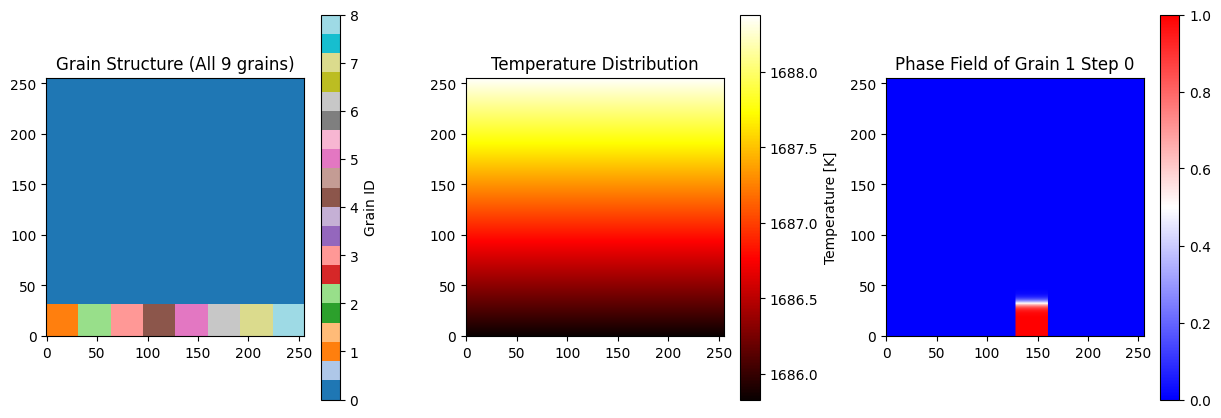

In [263]:
# --- 初期化 ---
phi_cpu = np.zeros((number_of_grain, nx, ny), dtype=np.float32)
seed_height = 32
factor = 2 / delta

number_of_solidgrains = number_of_grain - 1 # 結晶粒の数
grain_width = nx // number_of_solidgrains

for l in range(nx):
    # X座標に基づいて、どの固相IDに属するか決める
    # 例: l=0~30 -> ID=1, l=31~60 -> ID=2 ...
    grain_id = int(l // grain_width) + 1
    if grain_id > number_of_solidgrains:
        grain_id = number_of_solidgrains
    for m in range(ny):
        y = m * dy
        dist = y - (seed_height * dy)
        phi_solid = 0.5 * (1.0 - np.tanh(factor * dist))
        phi_cpu[grain_id, l, m] = phi_solid
        phi_cpu[0, l, m] = 1.0 - phi_solid

temp_cpu = np.zeros((nx, ny), dtype=np.float64)
for m in range(ny):
    temp_cpu[:, m] = T_melt -1 + G * (m - seed_height) * dy

phase_map = np.argmax(phi_cpu, axis=0)

fig = plt.figure(figsize=(15, 5))
plt.subplots_adjust(wspace=0.3) 

# 1. 結晶粒マップ (Grain Map)
plt.subplot(1, 3, 1)
# 'tab20' や 'nipy_spectral' などの多色カラーマップを使うと綺麗に分かれます
# 液相(0)と固相(1~)が別の色で表示されます
plt.imshow(phase_map.T, cmap='tab20', origin='lower', interpolation='nearest')
plt.colorbar(ticks=range(number_of_grain), label='Grain ID')
plt.title(f"Grain Structure (All {number_of_grain} grains)")

# 2. 温度場 (Temperature)
plt.subplot(1, 3, 2)
plt.imshow(temp_cpu.T, cmap='hot', origin='lower')
plt.colorbar(label='Temperature [K]')
plt.title("Temperature Distribution")
plt.subplot(1,3,3)
plt.imshow(phi_cpu[5].T, cmap='bwr', origin='lower',vmax=1.0,vmin=0.0)
plt.colorbar()
plt.title("Phase Field of Grain 1 Step 0")
plt.savefig("result/periodic/ani/step_0.png")
plt.show()

In [264]:
# GPUメモリへ転送
d_phi = cuda.to_device(phi_cpu)
d_phi_new = cuda.to_device(phi_cpu)
d_temp = cuda.to_device(temp_cpu)
d_wij = cuda.to_device(wij)
d_aij = cuda.to_device(aij)
d_mij = cuda.to_device(mij)

In [265]:
# CUDA実行構成
threadsperblock = (16, 16)
blockspergrid_x = math.ceil(nx / threadsperblock[0])
blockspergrid_y = math.ceil(ny / threadsperblock[1])
blockspergrid = (blockspergrid_x, blockspergrid_y)

In [ ]:
# --- メインループ ---
cooling_rate = np.float64(G * V_pulling * dt)

for nstep in range(1, nsteps + 1):
    # 温度更新
    kernel_update_temp[blockspergrid, threadsperblock](d_temp, cooling_rate, nx, ny)
    
    # フェーズフィールド更新
    kernel_update_phasefield[blockspergrid, threadsperblock](
        d_phi, d_phi_new, d_temp, d_wij, d_aij, d_mij, nx, ny, number_of_grain, dx, dt, T_melt, latent
    )
    
    # ポインタの入れ替え（d_phiに最新結果を入れる）
    d_phi, d_phi_new = d_phi_new, d_phi

    if nstep % 200000 == 0:
        current_phi = d_phi.copy_to_host()
        current_temp = d_temp.copy_to_host()
        print(f"Step {nstep} done.")
        print("Tmin:", np.min(current_temp), "Tmax:", np.max(current_temp))
        phase_map = np.argmax(current_phi, axis=0)
    
        fig = plt.figure(figsize=(15,5))
        plt.subplots_adjust(wspace=0.3) 
        plt.subplot(1,3,1)
        plt.imshow(phase_map.T, cmap='tab20', origin='lower', interpolation='nearest')
        plt.colorbar(ticks=range(number_of_grain), label='Grain ID')
        plt.title(f"Grains Step {nstep}")

        plt.subplot(1,3,2)
        plt.imshow(current_temp.T, cmap='hot', origin='lower')
        plt.title(f"Temperature Step {nstep}")
        plt.colorbar()
        plt.subplot(1,3,3)
        plt.imshow(current_phi[8].T, cmap='bwr', origin='lower',vmax=1.0,vmin=0.0)
        plt.colorbar()
        plt.title(f"Phase Field of Grain 8 Step {nstep}")
        plt.savefig(f"result/periodic/ani/step_{nstep}.png")
        plt.close()


Step 200000 done.
Tmin: 1675.829999979773 Tmax: 1678.379999979773
